In [ ]:
import sys
import os

# Dynamically find the project root (OR_SUC) so it can be run from anywhere
current_dir = os.getcwd()
while current_dir != '/' and not (os.path.exists(os.path.join(current_dir, 'src')) and os.path.exists(os.path.join(current_dir, 'data'))):
    current_dir = os.path.dirname(current_dir)
if current_dir != '/':
    os.chdir(current_dir)
    sys.path.append(os.path.abspath('src'))


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import gurobi_logtools as glt

# Analyse the results all methods

In [3]:
theta_list = [1e-1]  # Wasserstein radius. Bonferroni approximation requires small theta for feasibility
epsilon_list = [0.2, 0.1]  # the risk level
gurobi_seed_list_allmethods = [i for i in range(0, 10000*30, 10000)] 
num_gen_list = [100]  # the number of thermal generators
N_WDR_list = [50]  # the number of scenarios for the WDRJCC
load_scaling_factor_list = [1]  # [1] the scaling factor for the load
T_list = [1, 2, 3, 4, 5]
bearable_cost_prop_list = [1.03]
network_name = 'case24_ieee_rts'
Fgap = 0.001
quadra_cost = True
bigM = 1e5
thread=4
timelimit = 3600

param_comb = list(itertools.product(load_scaling_factor_list, epsilon_list, theta_list, T_list, num_gen_list, N_WDR_list, bearable_cost_prop_list))
save_path_root = os.path.join(os.getcwd(), 'results', f'SUC_epstheta_results_bigM{int(bigM)}_thread{thread}')

# this is to compare other three linear approx schemes
def str_list(l):
    return f'[{", ".join([str(i) for i in l])}]'
def mynanmax(n):
    # if all nan, return nan; otherwise, return the nanmax
    return np.nan if all(np.isnan(i) for i in n) else np.nanmax(n)
def mynanmin(n):
    # if all nan, return nan; otherwise, return the nanmin
    return np.nan if all(np.isnan(i) for i in n) else np.nanmin(n)

def convert(n):
    # return the original number if it is not None nor nan, otherwise return nan
    if (n is None) or (np.isnan(n)):
        return np.nan
    else:
        return n

def n_nonan(n):
    # return the number of non-nan in the list
    return sum([1 for i in n if not np.isnan(i)])

def mynanmean(n):
    # if all nan, return nan; otherwise, return the nanmean
    return np.nan if all(np.isnan(i) for i in n) else np.nanmean(n)

def sortedmean(n, first_k):
    return mynanmean(np.sort(n)[:first_k])

## the process of the following function is quite similar to the previous "load_results" function, just extended to other three benchmarks
def load_all_results(param_comb, save_path_root):
    res_df = []
    res_all_df = []
    for param in param_comb:
        load_scaling_factor, epsilon, theta, T, num_gen, N_WDR, bearable_cost_prop = param
        min_cost_proposed_list = []
        reliability_proposed_list = []
        reliability_proposed_base_list = []
        time_proposed_list = []

        min_cost_ori_list = []
        min_cost_ori_prop_diff_list = []
        reliability_ori_list = []
        reliability_ori_base_list = []
        time_ori_list = []
        
        proposed_status_list = []
        ori_status_list = []
        
        break_flag = False
        
        for gurobi_seed in gurobi_seed_list_allmethods:
            res_save_path_proposed = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_proposed_eps_T{T}{"quadra_cost" if quadra_cost else ""}_bc{bearable_cost_prop}.npy')

            res_save_path_ori = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_ori_eps_T{T}{"quadra_cost" if quadra_cost else ""}_bc{bearable_cost_prop}.npy')

            if not os.path.exists(res_save_path_proposed) or not os.path.exists(res_save_path_ori):
                break_flag = True
                break
            
            res_proposed = np.load(res_save_path_proposed, allow_pickle=True).item()
            res_ori = np.load(res_save_path_ori, allow_pickle=True).item()
            
            
            min_cost_proposed = res_proposed['min_cost (USD)']
            reliability_proposed = res_proposed['reliability_test (%)']
            time_proposed = res_proposed['t_solve (s)']
            reliability_proposed_base = res_proposed['reliability_test_base (%)']
            
            
            min_cost_ori = np.load(res_save_path_ori, allow_pickle=True).item()['min_cost (USD)']
            time_ori = np.load(res_save_path_ori, allow_pickle=True).item()['t_solve (s)']
            reliability_ori = np.load(res_save_path_ori, allow_pickle=True).item()['reliability_test (%)']
            reliability_ori_base = np.load(res_save_path_ori, allow_pickle=True).item()['reliability_test_base (%)']
            
            # append to list
            min_cost_proposed_list.append(convert(min_cost_proposed))
            reliability_proposed_list.append(convert(reliability_proposed))
            reliability_proposed_base_list.append(convert(reliability_proposed_base))
            time_proposed_list.append(convert(time_proposed))

            min_cost_ori_list.append(convert(min_cost_ori))
            reliability_ori_list.append(convert(reliability_ori))
            reliability_ori_base_list.append(convert(reliability_ori_base))
            time_ori_list.append(convert(time_ori))

            min_cost_ori_prop_diff_list.append(convert((min_cost_proposed - min_cost_ori)/min_cost_proposed))

            proposed_status = "OPTIMAL" if not np.isnan(min_cost_proposed) else "INFEASIBLE or NO SOLUTION"
            ori_status = "OPTIMAL" if not np.isnan(min_cost_ori) else "INFEASIBLE or NO SOLUTION"

            proposed_status_list.append(proposed_status)
            ori_status_list.append(ori_status)
            
            # append to df for each seed
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'SFLA',
                'Obj. Diff. (%)': 0,
                'time': time_proposed_list[-1],
                'Min Cost': min_cost_proposed_list[-1],
                'status': proposed_status,
                'bearable_cost_prop': bearable_cost_prop,
                'reliability_test (%)': reliability_proposed_list[-1],
                'reliability_test_base (%)': reliability_proposed_base_list[-1],
                'reliability_improvement (%)': reliability_proposed_list[-1] - reliability_proposed_base_list[-1],
                'reli_impro_diff (%)': 0,
                'T': T,
                'seed': gurobi_seed,
            }, index=[0]))
            
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'LA',
                'time': time_ori_list[-1],
                'Obj. Diff. (%)': min_cost_ori_prop_diff_list[-1]*100,
                'Min Cost': min_cost_ori_list[-1],
                'status': ori_status,
                'bearable_cost_prop': bearable_cost_prop,
                'reliability_test (%)': reliability_ori_list[-1],
                'reliability_test_base (%)': reliability_ori_base_list[-1],
                'reliability_improvement (%)': reliability_ori_list[-1] - reliability_ori_base_list[-1],
                'reli_impro_diff (%)': reliability_proposed_list[-1] - reliability_ori_list[-1],
                'T': T,
                'seed': gurobi_seed,
            }, index=[0]))
        
    res_all_df = pd.concat(res_all_df, ignore_index=True)
    return res_all_df

res_all_methods_all_df = load_all_results(param_comb, save_path_root)
res_all_methods_all_df


,eps,theta,num_gen,N_WDR,method,Obj. Diff. (%),time,Min Cost,status,bearable_cost_prop,reliability_test (%),reliability_test_base (%),reliability_improvement (%),reli_impro_diff (%),T,seed
0,0.2,0.1,100,50,SFLA,0.000000e+00,0.234123,29232.284070,OPTIMAL,1.03,99.48,95.58,3.90,0.00,1,0
1,0.2,0.1,100,50,LA,1.576772e-07,3.250309,29232.284024,OPTIMAL,1.03,99.46,95.58,3.88,0.02,1,0
2,0.2,0.1,100,50,SFLA,0.000000e+00,0.300863,31901.050637,OPTIMAL,1.03,99.86,93.74,6.12,0.00,1,10000
3,0.2,0.1,100,50,LA,-7.600950e-07,40.711973,31901.050880,OPTIMAL,1.03,99.86,93.74,6.12,0.00,1,10000
4,0.2,0.1,100,50,SFLA,0.000000e+00,0.194365,31725.314380,OPTIMAL,1.03,99.70,92.46,7.24,0.00,1,20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.1,0.1,100,50,LA,1.160593e-08,1165.099258,168728.759778,OPTIMAL,1.03,98.06,85.24,12.82,0.00,5,270000
596,0.1,0.1,100,50,SFLA,0.000000e+00,1.644053,171969.848199,OPTIMAL,1.03,99.84,95.30,4.54,0.00,5,280000
597,0.1,0.1,100,50,LA,-8.461899e-14,769.233868,171969.848199,OPTIMAL,1.03,99.84,95.30,4.54,0.00,5,280000
598,0.1,0.1,100,50,SFLA,0.000000e+00,1.018054,167534.638128,OPTIMAL,1.03,99.60,95.48,4.12,0.00,5,290000


In [4]:
res_all_methods_all_df["Obj. Diff. (%)"].describe()

count    6.000000e+02
mean     1.214823e-06
std      3.887827e-05
min     -1.144276e-04
25%     -3.170967e-14
50%      0.000000e+00
75%      0.000000e+00
max      9.332605e-04
Name: Obj. Diff. (%), dtype: float64

In [5]:
res_all_methods_all_df['reli_impro_diff (%)'].describe()

count    600.000000
mean      -0.000500
std        0.011632
min       -0.280000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.020000
Name: reli_impro_diff (%), dtype: float64

In [6]:
### plotting

# configure the plotting
import seaborn as sns
import matplotlib.pyplot as plt
# set plotting options, font size, and style to Academic theme (Times New Roman, etc.)
# Set matplotlib style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    "mathtext.fontset": "cm",
})

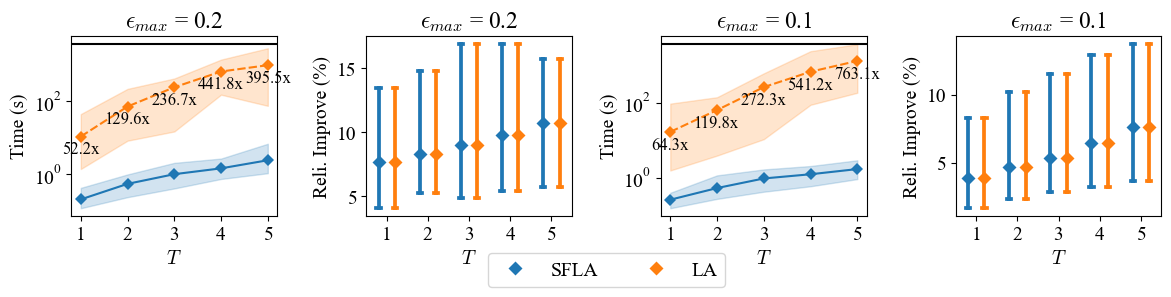

In [ ]:
num_seed = 30
markers = ['D', 'D']
seed_threshold = gurobi_seed_list_allmethods[:num_seed][-1]+1 # +1 to include the last seed (avoid numerical error)
T_list_plot = T_list
N_WDR = N_WDR_list[0]

fig, axs = plt.subplots(1, 4, figsize=(3*4, 3))

for ii, eps in enumerate(epsilon_list):
    ax = axs[2*ii+0]
    res_all_df_plot = res_all_methods_all_df[res_all_methods_all_df["eps"]==eps].copy()
    sns.lineplot(x='T', y='time', data=res_all_df_plot, ax=ax, 
            hue='method', estimator='mean', errorbar=('pi', 95), style='method', markers=markers, n_boot=1000, markersize=6, markeredgewidth=0)
    # plot a horizontal line at timelimit
    ax.axhline(timelimit, color='black', linestyle='-')
    ax.set_title(fr'$\epsilon_{{max}}$ = {eps}')
    # set xticks
    ax.set_xticks(T_list_plot)
    # set x axis
    ax.set_xlabel('$T$')
    ax.set_ylabel('Time (s)')
    # log y scale
    ax.set_yscale('log')
    # set ylim
    # ax.set_ylim(.5, timelimit*1.5)
    # do not display the legend
    ax.get_legend().remove()
    # calculate the speedup of the mean time of the two methods, and display it on the plot
    mean_time_proposed = res_all_df_plot[res_all_df_plot['method']=='SFLA'].groupby('T')['time'].mean()
    mean_time_ori = res_all_df_plot[res_all_df_plot['method']=='LA'].groupby('T')['time'].mean()
    speedup = mean_time_ori / mean_time_proposed
    for i, T in enumerate(T_list_plot):
        if T in speedup.index:
            ax.text(T, mean_time_ori[T]*0.7, f'{speedup[T]:.1f}x', ha='center', va='top', fontsize=12, color='black', zorder=20)

    ax = axs[2*ii+1]
    sns.pointplot(x='T', y='reliability_improvement (%)', data=res_all_df_plot, ax=ax, 
             hue='method', dodge=.4, estimator='mean', markers=['D', 'D', 'D', 'D'], linestyle='none', errorbar=('pi', 95), zorder=10, capsize = .1, markersize=5)
    
    # plot reliability_test_base (%) as black point plot
    ax.set_title(fr'$\epsilon_{{max}}$ = {eps}')
    # set xticks
    # ax.set_xticks(T_list_plot)
    ax.get_legend().remove()
    ax.set_xlabel('$T$')
    ax.set_ylabel('Reli. Improve (%)')

    # similar, calculate the improvement of the mean reliability of the two methods, and display it on the plot
    mean_reliability_proposed = res_all_df_plot[res_all_df_plot['method']=='SFLA'].groupby('T')['reliability_improvement (%)'].mean()
    mean_reliability_ori = res_all_df_plot[res_all_df_plot['method']=='LA'].groupby('T')['reliability_improvement (%)'].mean()
    diff = mean_reliability_proposed - mean_reliability_ori
    # Get the x-tick locations, which correspond to the categorical 'T' values
    xtick_locs = ax.get_xticks()

    # Iterate through the improvement Series to place the text
    # for i, T_val in enumerate(diff.index):
    #     # The x-coordinate is the tick location
    #     x_coord = xtick_locs[i]

    #     # The y-coordinate can be based on the higher of the two mean values for that T
    #     y_coord = max(mean_reliability_proposed[T_val], mean_reliability_ori[T_val])

    #     # The text to display
    #     text = f'{diff[T_val]:.2f}%'

    #     # Add the text to the plot with a slight vertical offset for better visibility
    #     ax.text(x_coord+0.3, y_coord + 0.5, text, ha='center', va='bottom', fontsize=12, color='black', zorder=20)

    
# create my own legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.52, .15), ncol=2)
plt.tight_layout()
# plt.subplots_adjust(top=0.87)
# save the figure
path_name = os.path.join(os.path.dirname(save_path_root), 'figure', f'suc_epstheta_time_{network_name}{"quadra_cost" if quadra_cost else ""}_Fgap{Fgap}_allT_N{N_WDR}.pdf')
if not os.path.exists(os.path.dirname(path_name)):
    os.makedirs(os.path.dirname(path_name))
plt.savefig(path_name)

# Now comparing optimising theta and epsilon

In [8]:
theta_list = [1e-1]  # Wasserstein radius. Bonferroni approximation requires small theta for feasibility
epsilon_list = [0.1]  # the risk level
gurobi_seed_list_allmethods = [i for i in range(0, 10000*30, 10000)] 
num_gen_list = [100]  # the number of thermal generators
N_WDR_list = [50]  # the number of scenarios for the WDRJCC
load_scaling_factor_list = [1]  # [1] the scaling factor for the load
T_list = [6, 8, 10, 12, 14]
bearable_cost_prop_list = [1.01, 1.03, 1.05]
network_name = 'case24_ieee_rts'
Fgap = 0.001
quadra_cost = True
bigM = 1e5
thread=4
timelimit = 3600

param_comb = list(itertools.product(load_scaling_factor_list, epsilon_list, theta_list, T_list, num_gen_list, N_WDR_list, bearable_cost_prop_list))
save_path_root = os.path.join(os.getcwd(), 'results', f'SUC_epstheta_results_bigM{int(bigM)}_thread{thread}')

# this is to compare other three linear approx schemes
def str_list(l):
    return f'[{", ".join([str(i) for i in l])}]'
def mynanmax(n):
    # if all nan, return nan; otherwise, return the nanmax
    return np.nan if all(np.isnan(i) for i in n) else np.nanmax(n)
def mynanmin(n):
    # if all nan, return nan; otherwise, return the nanmin
    return np.nan if all(np.isnan(i) for i in n) else np.nanmin(n)

def convert(n):
    # return the original number if it is not None nor nan, otherwise return nan
    if (n is None) or (np.isnan(n)):
        return np.nan
    else:
        return n

def n_nonan(n):
    # return the number of non-nan in the list
    return sum([1 for i in n if not np.isnan(i)])

def mynanmean(n):
    # if all nan, return nan; otherwise, return the nanmean
    return np.nan if all(np.isnan(i) for i in n) else np.nanmean(n)

def sortedmean(n, first_k):
    return mynanmean(np.sort(n)[:first_k])

## the process of the following function is quite similar to the previous "load_results" function, just extended to other three benchmarks
def load_all_results(param_comb, save_path_root):
    res_df = []
    res_all_df = []
    for param in param_comb:
        load_scaling_factor, epsilon, theta, T, num_gen, N_WDR, bearable_cost_prop = param
        min_cost_proposed_eps_list = []
        reliability_proposed_eps_list = []
        reliability_proposed_eps_base_list = []
        time_proposed_eps_list = []

        min_cost_proposed_theta_list = []
        min_cost_theta_eps_diff_list = []
        reliability_proposed_theta_list = []
        reliability_proposed_theta_base_list = []
        time_proposed_theta_list = []

        proposed_eps_status_list = []
        proposed_theta_status_list = []

        break_flag = False
        
        for gurobi_seed in gurobi_seed_list_allmethods:
            res_save_path_proposed_eps = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_proposed_eps_T{T}{"quadra_cost" if quadra_cost else ""}_bc{bearable_cost_prop}.npy')

            res_save_path_proposed_theta = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_proposed_theta_T{T}{"quadra_cost" if quadra_cost else ""}_bc{bearable_cost_prop}.npy')

            if not os.path.exists(res_save_path_proposed_eps) or not os.path.exists(res_save_path_proposed_theta):
                break_flag = True
                break

            res_proposed_eps = np.load(res_save_path_proposed_eps, allow_pickle=True).item()
            res_proposed_theta = np.load(res_save_path_proposed_theta, allow_pickle=True).item()


            min_cost_proposed_eps = res_proposed_eps['min_cost (USD)']
            reliability_proposed_eps = res_proposed_eps['reliability_test (%)']
            time_proposed_eps = res_proposed_eps['t_solve (s)']
            reliability_proposed_eps_base = res_proposed_eps['reliability_test_base (%)']


            min_cost_proposed_theta = res_proposed_theta['min_cost (USD)']
            time_proposed_theta = res_proposed_theta['t_solve (s)']
            reliability_proposed_theta = res_proposed_theta['reliability_test (%)']
            reliability_proposed_theta_base = res_proposed_theta['reliability_test_base (%)']

            # append to list
            min_cost_proposed_eps_list.append(convert(min_cost_proposed_eps))
            reliability_proposed_eps_list.append(convert(reliability_proposed_eps))
            reliability_proposed_eps_base_list.append(convert(reliability_proposed_eps_base))
            time_proposed_eps_list.append(convert(time_proposed_eps))

            min_cost_proposed_theta_list.append(convert(min_cost_proposed_theta))
            reliability_proposed_theta_list.append(convert(reliability_proposed_theta))
            reliability_proposed_theta_base_list.append(convert(reliability_proposed_theta_base))
            time_proposed_theta_list.append(convert(time_proposed_theta))

            min_cost_theta_eps_diff_list.append(convert((min_cost_proposed_eps - min_cost_proposed_theta)/min_cost_proposed_eps))

            proposed_eps_status = "OPTIMAL" if not np.isnan(min_cost_proposed_eps) else "INFEASIBLE or NO SOLUTION"
            proposed_theta_status = "OPTIMAL" if not np.isnan(min_cost_proposed_theta) else "INFEASIBLE or NO SOLUTION"

            proposed_eps_status_list.append(proposed_eps_status)
            proposed_theta_status_list.append(proposed_theta_status)

            # append to df for each seed
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'SFLA Risk',
                'Obj. Diff. (%)': 0,
                'time': time_proposed_eps_list[-1],
                'Min Cost': min_cost_proposed_eps_list[-1],
                'status': proposed_eps_status,
                'bearable_cost_prop': bearable_cost_prop,
                'reliability_test (%)': reliability_proposed_eps_list[-1],
                'reliability_test_base (%)': reliability_proposed_eps_base_list[-1],
                'reliability_improvement (%)': reliability_proposed_eps_list[-1] - reliability_proposed_eps_base_list[-1],
                'T': T,
                'seed': gurobi_seed,
            }, index=[0]))
            
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'SFLA Rad',
                'time': time_proposed_theta_list[-1],
                'Obj. Diff. (%)': min_cost_theta_eps_diff_list[-1]*100,
                'Min Cost': min_cost_proposed_theta_list[-1],
                'status': proposed_theta_status,
                'bearable_cost_prop': bearable_cost_prop,
                'reliability_test (%)': reliability_proposed_theta_list[-1],
                'reliability_test_base (%)': reliability_proposed_theta_base_list[-1],
                'reliability_improvement (%)': reliability_proposed_theta_list[-1] - reliability_proposed_theta_base_list[-1],
                'T': T,
                'seed': gurobi_seed,
            }, index=[0]))
        
    res_all_df = pd.concat(res_all_df, ignore_index=True)
    return res_all_df

res_all_methods_all_df = load_all_results(param_comb, save_path_root)
res_all_methods_all_df


,eps,theta,num_gen,N_WDR,method,Obj. Diff. (%),time,Min Cost,status,bearable_cost_prop,reliability_test (%),reliability_test_base (%),reliability_improvement (%),T,seed
0,0.1,0.1,100,50,SFLA Risk,0.000000e+00,7.289214,94731.699015,OPTIMAL,1.01,95.04,91.44,3.60,6,0
1,0.1,0.1,100,50,SFLA Rad,-1.536119e-14,1.994796,94731.699015,OPTIMAL,1.01,95.42,91.44,3.98,6,0
2,0.1,0.1,100,50,SFLA Risk,0.000000e+00,2.815948,191336.529966,OPTIMAL,1.01,98.08,91.70,6.38,6,10000
3,0.1,0.1,100,50,SFLA Rad,-1.381187e-09,6.286022,191336.529969,OPTIMAL,1.01,97.94,91.70,6.24,6,10000
4,0.1,0.1,100,50,SFLA Risk,0.000000e+00,1.250011,175348.330841,OPTIMAL,1.01,96.94,90.82,6.12,6,20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,0.1,0.1,100,50,SFLA Rad,-2.449547e-11,6.638861,439133.261448,OPTIMAL,1.05,99.60,75.42,24.18,14,270000
896,0.1,0.1,100,50,SFLA Risk,0.000000e+00,6.936956,408295.284010,OPTIMAL,1.05,99.92,90.16,9.76,14,280000
897,0.1,0.1,100,50,SFLA Rad,-6.489606e-08,7.458632,408295.284275,OPTIMAL,1.05,99.96,90.16,9.80,14,280000
898,0.1,0.1,100,50,SFLA Risk,0.000000e+00,83.818037,288695.020421,OPTIMAL,1.05,99.52,81.60,17.92,14,290000


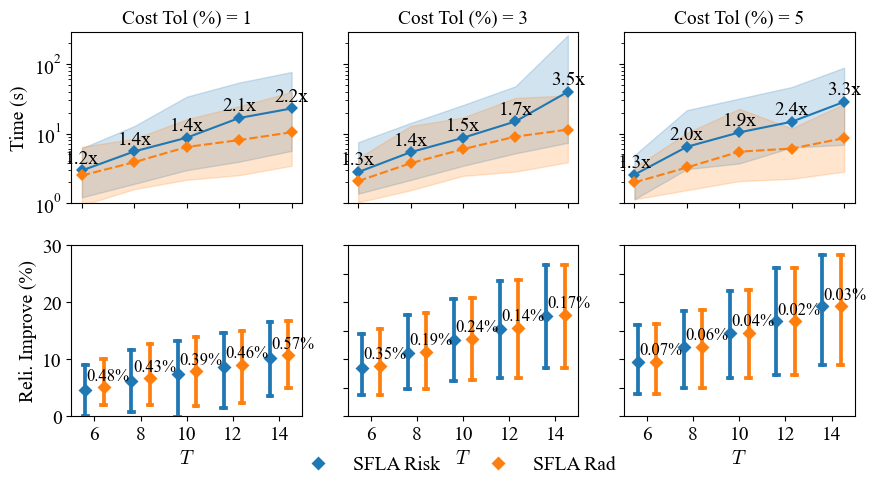

In [ ]:
num_seed = 30
markers = ['D', 'D']
seed_threshold = gurobi_seed_list_allmethods[:num_seed][-1]+1 # +1 to include the last seed (avoid numerical error)
T_list_plot = T_list
N_WDR = N_WDR_list[0]
eps = epsilon_list[0]

fig, axs = plt.subplots(2, 3, figsize=(9, 5))

for ii, bearable_cost_prop in enumerate(bearable_cost_prop_list):
    ax = axs[0, ii]
    res_all_df_plot = res_all_methods_all_df[(res_all_methods_all_df["eps"]==eps) & (res_all_methods_all_df["bearable_cost_prop"]==bearable_cost_prop)].copy()
    sns.lineplot(x='T', y='time', data=res_all_df_plot, ax=ax, 
            hue='method', estimator='mean', errorbar=('pi', 95), style='method', markers=markers, n_boot=1000, markersize=6, markeredgewidth=0)
    # plot a horizontal line at timelimit
    # ax.axhline(timelimit, color='black', linestyle='-')
    ax.set_title(fr'Cost Tol (%) = {(bearable_cost_prop-1)*100:.0f}', fontsize=14)
    # set xticks
    ax.set_xticks(T_list_plot)
    # set x axis
    ax.set_xlabel('')
    ax.set_ylabel('Time (s)')
    # log y scale
    ax.set_yscale('log')
    # set ylim
    ax.set_ylim(1, timelimit*0.08)
    # do not display the legend
    ax.get_legend().remove()
    # calculate the speedup of the mean time of the two methods, and display it on the plot
    mean_time_proposed_theta = res_all_df_plot[res_all_df_plot['method']=='SFLA Rad'].groupby('T')['time'].mean()
    mean_time_proposed_eps = res_all_df_plot[res_all_df_plot['method']=='SFLA Risk'].groupby('T')['time'].mean()
    speedup = mean_time_proposed_eps / mean_time_proposed_theta
    for i, T in enumerate(T_list_plot):
        if T in speedup.index:
            ax.text(T, mean_time_proposed_eps[T]*2, f'{speedup[T]:.1f}x', ha='center', va='top', fontsize=14, color='black', zorder=20)

    # set y tick label to white color and smaller font size
    ax.tick_params(axis='x', labelcolor='white', labelsize=1)
    if ii > 0:
        ax.tick_params(axis='y', labelcolor='white', labelsize=1)
        ax.set_ylabel('')

    ax = axs[1, ii]
    ax.set_ylim(0, 30)
    sns.pointplot(x='T', y='reliability_improvement (%)', data=res_all_df_plot, ax=ax, 
            hue='method', dodge=.4, estimator='mean', markers=['D', 'D', 'D', 'D'], linestyle='none', errorbar=('pi', 95), zorder=10, capsize = .1, markersize=5)

    # similar, calculate the improvement of the mean reliability of the two methods, and display it on the plot
    mean_reliability_proposed_theta = res_all_df_plot[res_all_df_plot['method']=='SFLA Rad'].groupby('T')['reliability_improvement (%)'].mean()
    mean_reliability_proposed_eps = res_all_df_plot[res_all_df_plot['method']=='SFLA Risk'].groupby('T')['reliability_improvement (%)'].mean()
    improvement = mean_reliability_proposed_theta - mean_reliability_proposed_eps
    # Get the x-tick locations, which correspond to the categorical 'T' values
    xtick_locs = ax.get_xticks()

    # Iterate through the improvement Series to place the text
    for i, T_val in enumerate(improvement.index):
        # The x-coordinate is the tick location
        x_coord = xtick_locs[i]

        # The y-coordinate can be based on the higher of the two mean values for that T
        y_coord = max(mean_reliability_proposed_theta[T_val], mean_reliability_proposed_eps[T_val])

        # The text to display
        text = f'{improvement[T_val]:.2f}%'

        # Add the text to the plot with a slight vertical offset for better visibility
        ax.text(x_coord+0.3, y_coord + 0.5, text, ha='center', va='bottom', fontsize=12, color='black', zorder=20)
    
    # plot reliability_test_base (%) as black point plot
    # ax.set_title(fr'Cost Tol (%) = {(bearable_cost_prop-1)*100:.0f}')
    # set xticks
    # ax.set_xticks(T_list_plot)
    ax.get_legend().remove()
    ax.set_xlabel('$T$')
    ax.set_ylabel('Reli. Improve (%)')
    if ii > 0:
        ax.tick_params(axis='y', labelcolor='white', labelsize=1)
        ax.set_ylabel('')

    
# create my own legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.52, .1), ncol=2, framealpha=0.)
plt.tight_layout()
# plt.subplots_adjust(top=0.87)
# save the figure
path_name = os.path.join(os.path.dirname(save_path_root), 'figure', f'suc_epstheta_evst_time_{network_name}{"quadra_cost" if quadra_cost else ""}_Fgap{Fgap}_allT_N{N_WDR}.pdf')
if not os.path.exists(os.path.dirname(path_name)):
    os.makedirs(os.path.dirname(path_name))
plt.savefig(path_name)